Target Captured at t = 66.16 s at distance 9.79 m


<Figure size 1200x800 with 0 Axes>

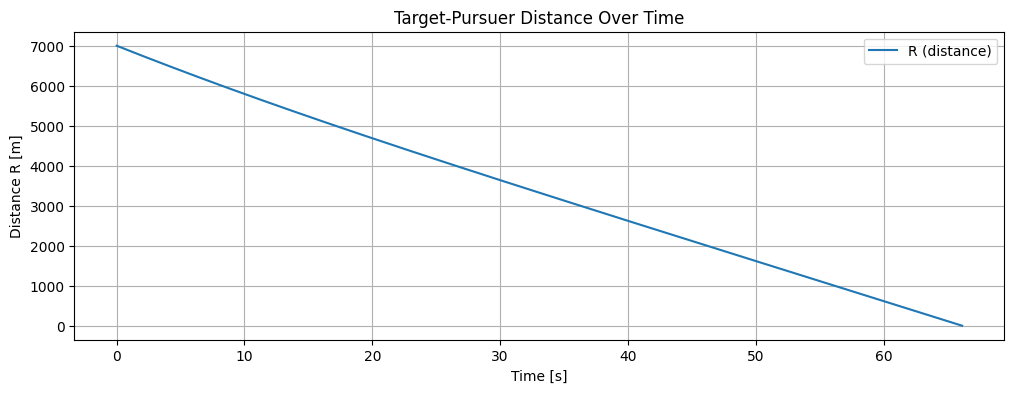

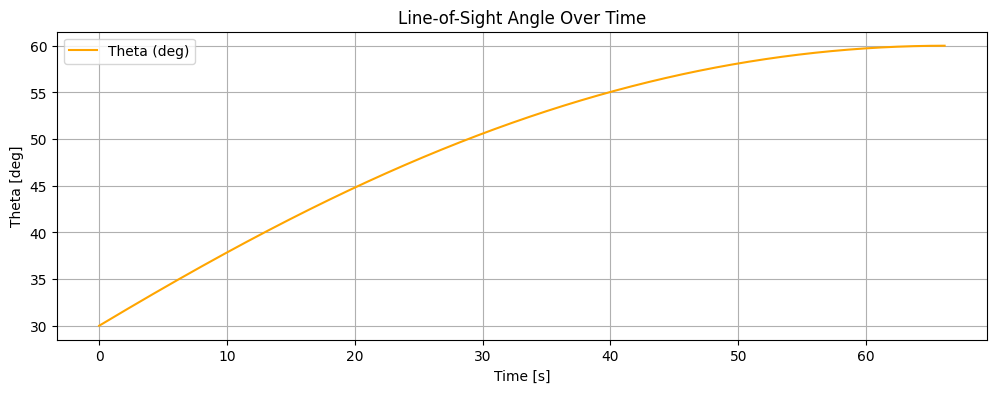

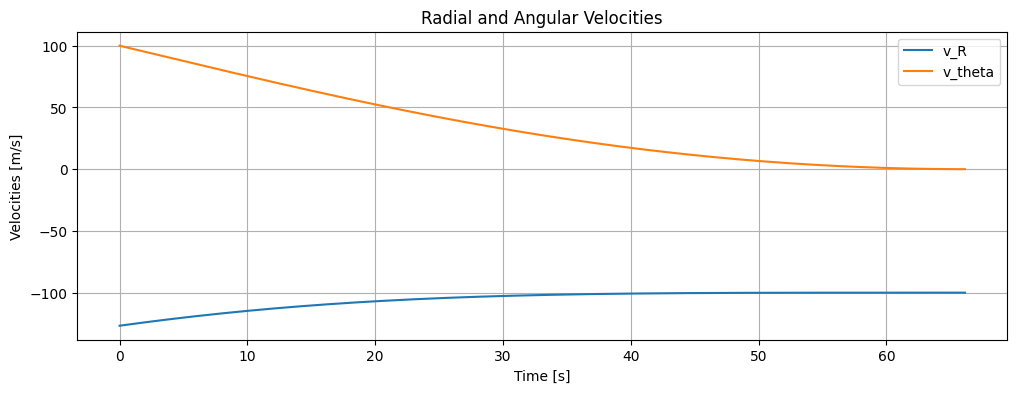

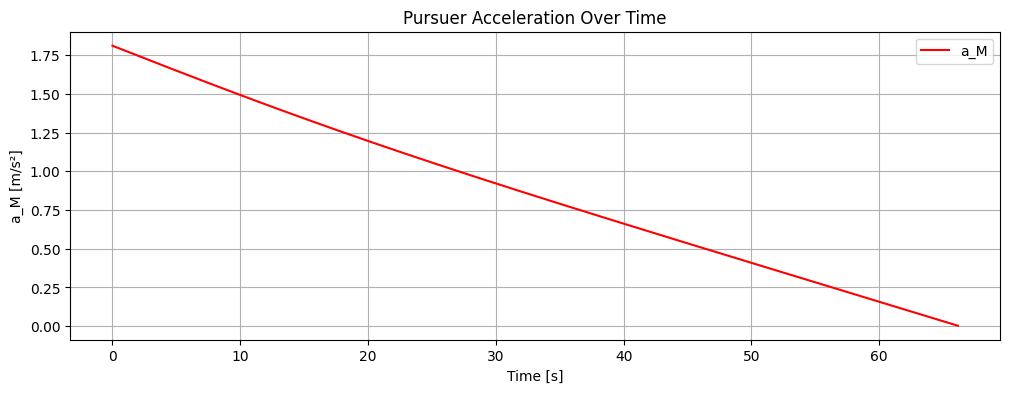

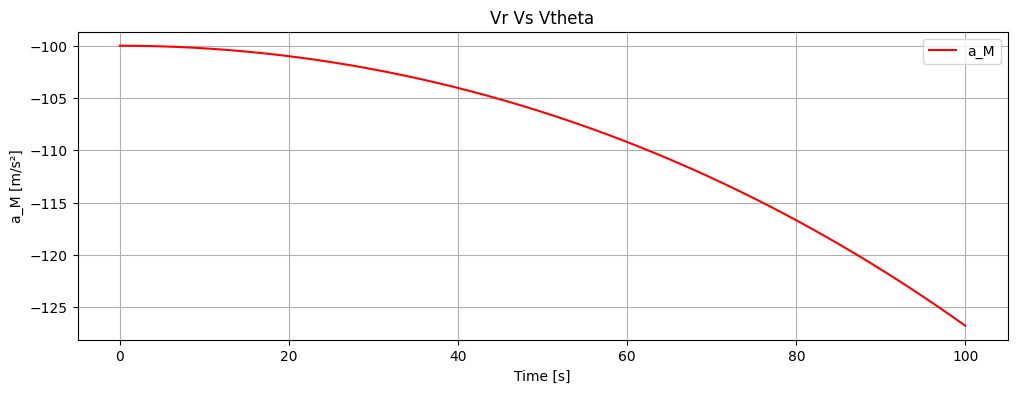

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

# Defining variables
r = 7000

v_T = 200
nu = 1.5
v_P = nu * v_T

theta = np.deg2rad(30)
alpha_T = np.deg2rad(60)
delta = np.deg2rad(0) # Pure Pursuit
alpha_P = theta + delta 

t = 0
dt = 0.01
Tmax = 100

vx_T = v_T * np.cos(alpha_T)
vy_T = v_T * np.sin(alpha_T)
vx_P = v_P * np.cos(alpha_P)
vy_P = v_P * np.sin(alpha_P)

x_P = 0
y_P = 0
x_T = r * np.cos(theta)
y_T = r * np.sin(theta)
CR = 10 # Capture Radius

# Lists to store trajectory points
x_T_points = []
y_T_points = []
x_P_points = []
y_P_points = [] 
R_points = []
theta_points = []
v_theta_points = []
v_R_points = []
a_M_points = []

min_R = float("inf")

R = np.sqrt((x_T - x_P)**2 + (y_T - y_P)**2) 

# Simulation loop
while R > CR and t<Tmax: # Capture Condition
    
    R = np.sqrt((x_T - x_P)**2 + (y_T - y_P)**2) 

    x_T_points.append(x_T)
    y_T_points.append(y_T)
    x_P_points.append(x_P)
    y_P_points.append(y_P)
    R_points.append(R)

    min_R = min(min_R, R)

    x_T += vx_T * dt
    y_T += vy_T * dt

    alpha_P = np.arctan2(y_T - y_P,x_T - x_P)

    vx_P = v_P * np.cos(alpha_P)
    vy_P = v_P * np.sin(alpha_P)
    
    x_P += vx_P * dt
    y_P += vy_P * dt    
    
    theta = np.arctan2(y_T - y_P, x_T - x_P)

    v_R = (vx_T - vx_P) * np.cos(theta) + (vy_T - vy_P) * np.sin(theta)
    v_theta = -(vx_T - vx_P) * np.sin(theta) + (vy_T - vy_P) * np.cos(theta)
    a_M = -v_R*v_theta / R

    t += dt
    
    theta_points.append(theta)
    v_R_points.append(v_R)
    v_theta_points.append(v_theta)
    a_M_points.append(a_M)

if R_points[-1] <= CR:
    print("Target Captured at t =", round(t,2), "s at distance", round(R_points[-1],2), "m")
else:
    print("Target Missed!")
    print("Closest approach =", round(min_R,2), "m at time", round(t,2), "s")

time = np.arange(len(R_points)) * dt

plt.figure(figsize=(12,8))

# --- 1) R ---
plt.figure(figsize=(12,4))
plt.plot(time, R_points, label="R (distance)")
plt.xlabel("Time [s]")
plt.ylabel("Distance R [m]")
plt.title("Target-Pursuer Distance Over Time")
plt.grid(True)
plt.legend()
plt.show()

# --- 2) Theta ---
plt.figure(figsize=(12,4))
plt.plot(time, np.rad2deg(theta_points), label="Theta (deg)", color="orange")
plt.xlabel("Time [s]")
plt.ylabel("Theta [deg]")
plt.title("Line-of-Sight Angle Over Time")
plt.grid(True)
plt.legend()
plt.show()

# --- 3) Velocities ---
plt.figure(figsize=(12,4))
plt.plot(time, v_R_points, label="v_R")
plt.plot(time, v_theta_points, label="v_theta")
plt.xlabel("Time [s]")
plt.ylabel("Velocities [m/s]")
plt.title("Radial and Angular Velocities")
plt.grid(True)
plt.legend()
plt.show()

# --- 4) Acceleration ---
plt.figure(figsize=(12,4))
plt.plot(time, a_M_points, label="a_M", color="r")
plt.xlabel("Time [s]")
plt.ylabel("a_M [m/s²]")
plt.title("Pursuer Acceleration Over Time")
plt.grid(True)
plt.legend()
plt.show()

# --- 5) VR vTheta ---
plt.figure(figsize=(12,4))
plt.plot(v_theta_points, v_R_points, label="a_M", color="r")
plt.xlabel("Time [s]")
plt.ylabel("a_M [m/s²]")
plt.title("Vr Vs Vtheta")
plt.grid(True)
plt.legend()
plt.show()

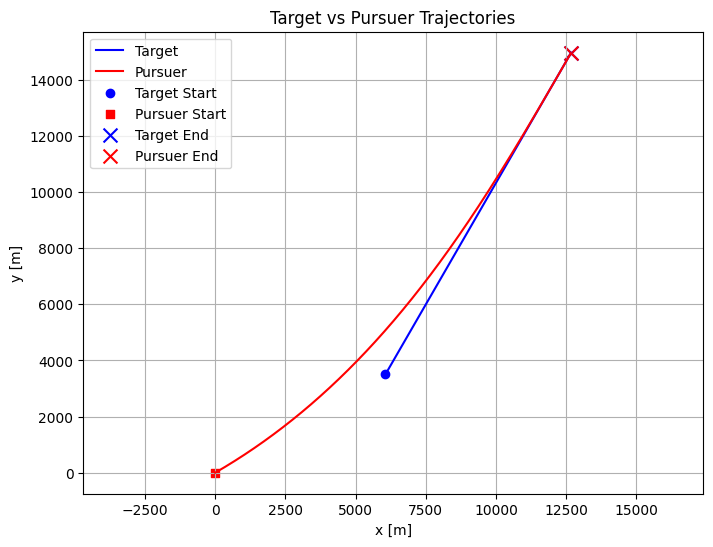

In [22]:
plt.figure(figsize=(8,6))

# Target trajectory
plt.plot(x_T_points, y_T_points, label="Target", color="blue")

# Pursuer trajectory
plt.plot(x_P_points, y_P_points, label="Pursuer", color="red")

# Starting positions
plt.scatter(x_T_points[0], y_T_points[0], color="blue", marker="o", label="Target Start")
plt.scatter(x_P_points[0], y_P_points[0], color="red", marker="s", label="Pursuer Start")

# Ending positions
plt.scatter(x_T_points[-1], y_T_points[-1], color="blue", marker="x", s=100, label="Target End")
plt.scatter(x_P_points[-1], y_P_points[-1], color="red", marker="x", s=100, label="Pursuer End")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Target vs Pursuer Trajectories")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()


In [23]:
# --- Reinitialize state variables and lists ---
r = 3000
v_T = 300
nu = 1
v_P = nu * v_T

theta = np.deg2rad(30)
alpha_T = np.deg2rad(170)
delta = np.deg2rad(0) # Pure Pursuit
alpha_P = theta + delta

t = 0
dt = 0.01
Tmax = 10

vx_T = v_T * np.cos(alpha_T)
vy_T = v_T * np.sin(alpha_T)
vx_P = v_P * np.cos(alpha_P)
vy_P = v_P * np.sin(alpha_P)

x_P = 0
y_P = 0
x_T = r * np.cos(theta)
y_T = r * np.sin(theta)
CR = 1 # Capture Radius

# Lists to store trajectory points
x_T_points = []
y_T_points = []
x_P_points = []
y_P_points = []
R_points = []
theta_points = []
v_theta_points = []
v_R_points = []
a_M_points = []
alpha_P_points = []
alpha_T_points = []

min_R = float("inf")
R = np.sqrt((x_T - x_P)**2 + (y_T - y_P)**2)
alpha_T_dot = np.pi/6.0

# Simulation loop

while R > CR and t < Tmax:

    x_T_points.append(x_T)
    y_T_points.append(y_T)
    x_P_points.append(x_P)
    y_P_points.append(y_P)
    R_points.append(R)

    min_R = min(min_R, R)

    
    alpha_T = alpha_T + alpha_T_dot * dt
    #alpha_T = (alpha_T + np.pi) % (2*np.pi) - np.pi

    vx_T = v_T * np.cos(alpha_T)
    vy_T = v_T * np.sin(alpha_T)

    x_T += vx_T * dt
    y_T += vy_T * dt

    alpha_P = np.arctan2(y_T - y_P, x_T - x_P)

    vx_P = v_P * np.cos(alpha_P)
    vy_P = v_P * np.sin(alpha_P)

    x_P += vx_P * dt
    y_P += vy_P * dt

    theta = np.arctan2(y_T - y_P, x_T - x_P)  # LOS angle

    v_R = (vx_T - vx_P) * np.cos(theta) + (vy_T - vy_P) * np.sin(theta)
    v_theta = -(vx_T - vx_P) * np.sin(theta) + (vy_T - vy_P) * np.cos(theta)
    a_M = -v_R * v_theta / max(R, 1e-9)

    theta_points.append(theta)
    v_R_points.append(v_R)
    v_theta_points.append(v_theta)
    a_M_points.append(a_M)
    alpha_T_points.append(alpha_T)

    t += dt
    R = np.hypot(x_T - x_P, y_T - y_P)

if R_points[-1] <= CR:
    print("Target Captured at t =", round(t,2), "s at distance", round(R_points[-1],2), "m")
else:
    print("Target Missed!")
    print("Closest approach =", round(min_R,2), "m at time", round(t,2), "s")

Target Missed!
Closest approach = 473.54 m at time 10.01 s


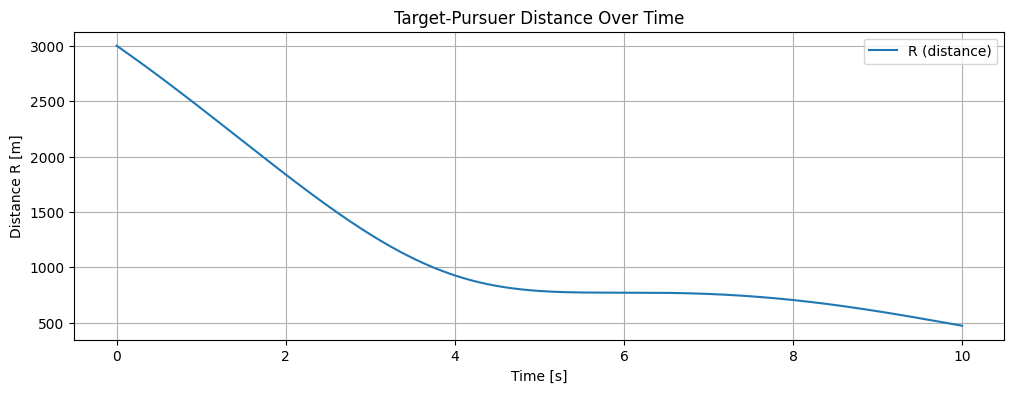

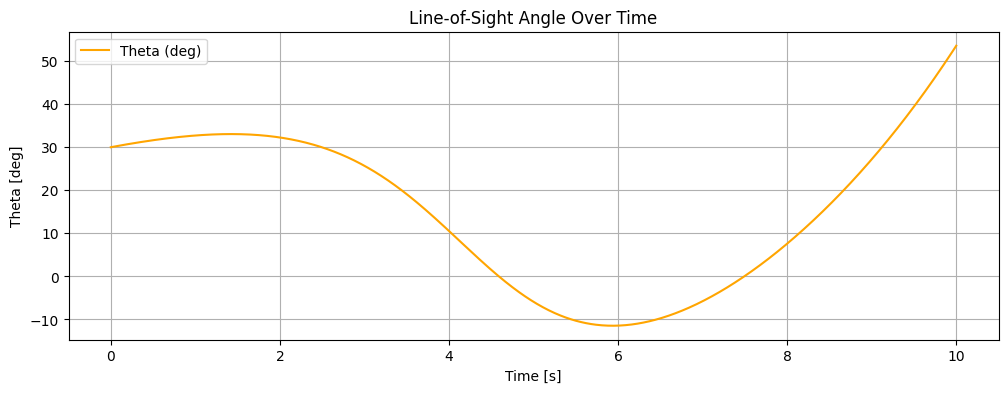

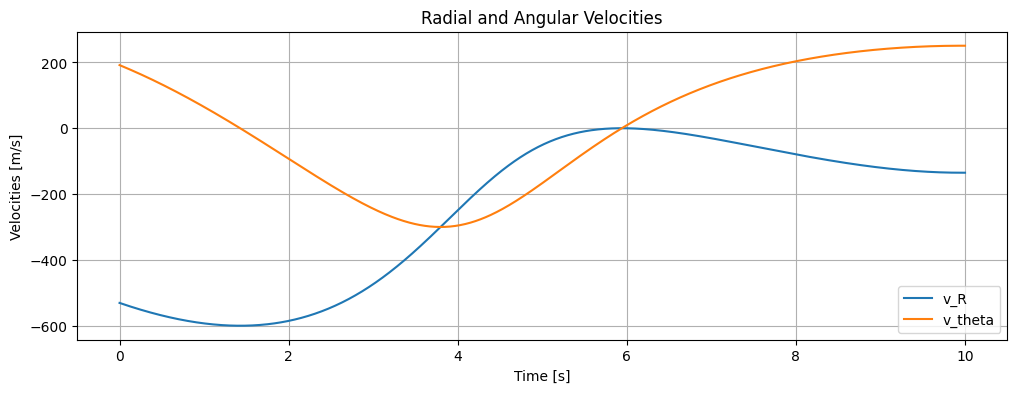

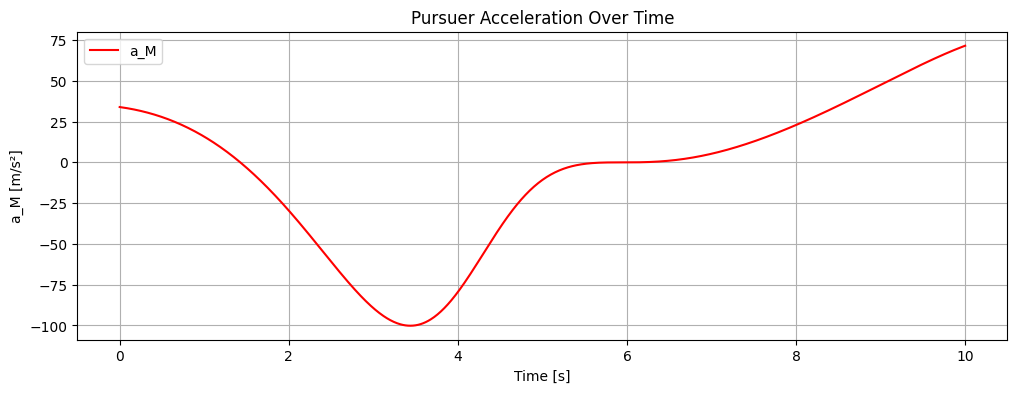

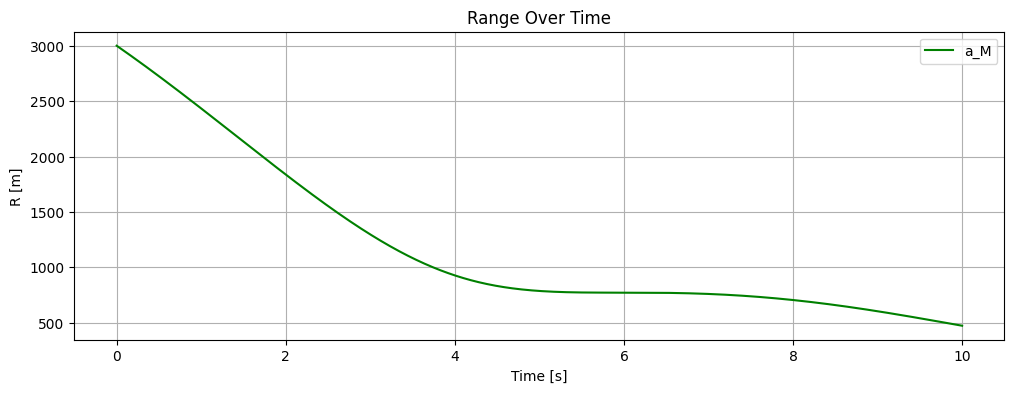

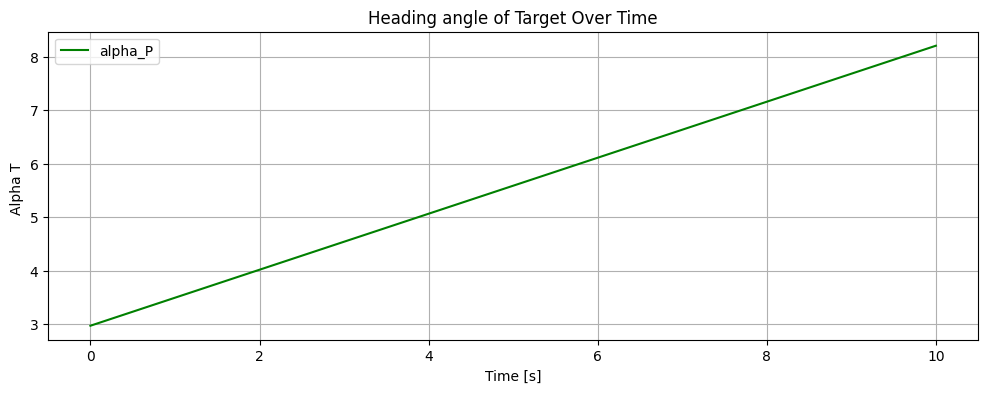

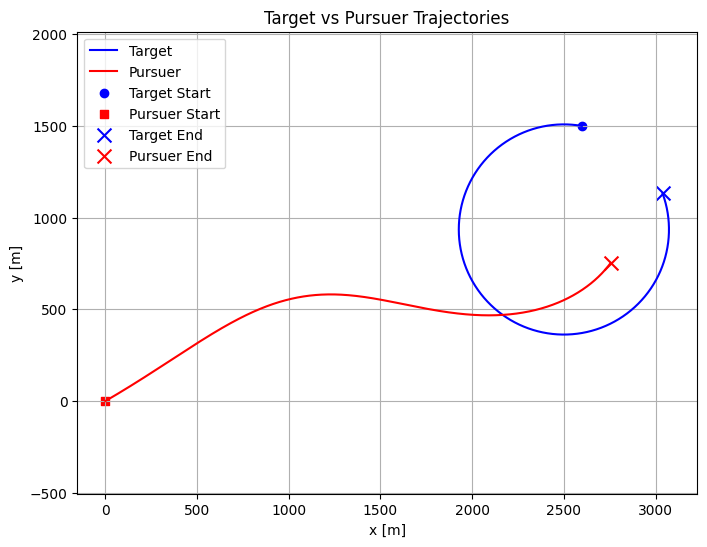

[np.float64(485.7632750490132), np.float64(484.4054973755913), np.float64(483.04754649296495), np.float64(481.6894592761229), np.float64(480.33127268945617), np.float64(478.97302378518833), np.float64(477.614749701769), np.float64(476.25648766223475), np.float64(474.89827497253594)]


In [24]:
time = np.arange(len(R_points)) * dt

plt.figure(figsize=(12, 4))
plt.plot(time, R_points, label="R (distance)")
plt.xlabel("Time [s]")
plt.ylabel("Distance R [m]")
plt.title("Target-Pursuer Distance Over Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time, np.rad2deg(theta_points), label="Theta (deg)", color="orange")
plt.xlabel("Time [s]")
plt.ylabel("Theta [deg]")
plt.title("Line-of-Sight Angle Over Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time, v_R_points, label="v_R")
plt.plot(time, v_theta_points, label="v_theta")
plt.xlabel("Time [s]")
plt.ylabel("Velocities [m/s]")
plt.title("Radial and Angular Velocities")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time, a_M_points, label="a_M", color="r")
plt.xlabel("Time [s]")
plt.ylabel("a_M [m/s²]")
plt.title("Pursuer Acceleration Over Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time, R_points, label="a_M", color="g")
plt.xlabel("Time [s]")
plt.ylabel("R [m]")
plt.title("Range Over Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time, alpha_T_points, label="alpha_P", color="g")
plt.xlabel("Time [s]")
plt.ylabel("Alpha T ")
plt.title("Heading angle of Target Over Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,6))

# Target trajectory
plt.plot(x_T_points, y_T_points, label="Target", color="blue")

# Pursuer trajectory
plt.plot(x_P_points, y_P_points, label="Pursuer", color="red")

# Starting positions
plt.scatter(x_T_points[0], y_T_points[0], color="blue", marker="o", label="Target Start")
plt.scatter(x_P_points[0], y_P_points[0], color="red", marker="s", label="Pursuer Start")

# Ending positions
plt.scatter(x_T_points[-1], y_T_points[-1], color="blue", marker="x", s=100, label="Target End")
plt.scatter(x_P_points[-1], y_P_points[-1], color="red", marker="x", s=100, label="Pursuer End")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Target vs Pursuer Trajectories")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()
print(R_points[-10:-1])